In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf

In [5]:
df = pd.read_csv("comercio-opiniones.csv")

/tmp/ipykernel_1621/2434488967.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("comercio-opiniones.csv")


In [6]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [8]:
df.isnull().sum()

,0
id,0
name,6760
asins,2
brand,0
categories,0
keys,0
manufacturer,0
reviews.date,39
reviews.dateAdded,10621
reviews.dateSeen,0


In [9]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,1.0,34131.000000,34627.000000,0.0,0.0
mean,111372787.0,0.630248,4.584573,NaN,NaN
std,NaN,13.215775,0.735653,NaN,NaN
min,111372787.0,0.000000,1.000000,NaN,NaN
25%,111372787.0,0.000000,4.000000,NaN,NaN
50%,111372787.0,0.000000,5.000000,NaN,NaN
75%,111372787.0,0.000000,5.000000,NaN,NaN
max,111372787.0,814.000000,5.000000,NaN,NaN


In [10]:
df["reviews.doRecommend"].value_counts()

,count
reviews.doRecommend,
True,32682
False,1384


In [11]:
df["reviews.rating"].value_counts()

,count
reviews.rating,
5.0,23775
4.0,8541
3.0,1499
1.0,410
2.0,402


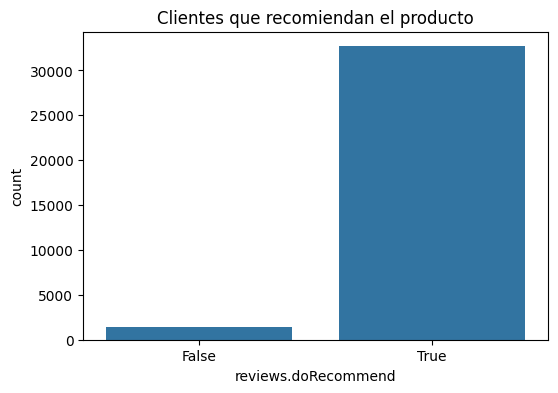

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="reviews.doRecommend", data=df)

plt.title("Clientes que recomiendan el producto")

plt.show()

In [13]:
df["reviews.rating"].value_counts().sort_index()

,count
reviews.rating,
1.0,410
2.0,402
3.0,1499
4.0,8541
5.0,23775


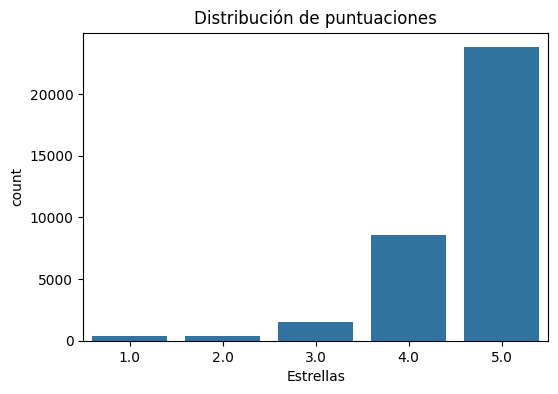

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="reviews.rating", data=df)

plt.title("Distribución de puntuaciones")

plt.xlabel("Estrellas")

plt.show()

In [15]:
df["sentimiento"] = df["reviews.rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

In [16]:
df["sentimiento"].value_counts()

,count
sentimiento,
1,32316
0,2344


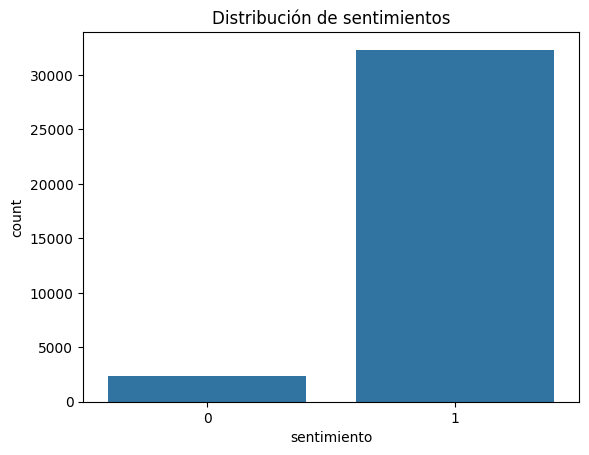

In [17]:
sns.countplot(
    x="sentimiento",
    data=df
)

plt.title("Distribución de sentimientos")
plt.show()

In [18]:
df["longitud_texto"] = df["reviews.text"].astype(str).apply(len)

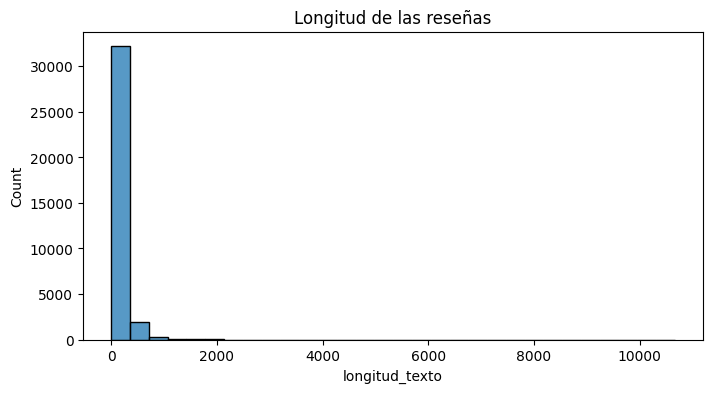

In [19]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["longitud_texto"],
    bins=30
)

plt.title("Longitud de las reseñas")
plt.show()

In [20]:
df["texto_completo"] = (
    df["reviews.title"].fillna("")
    + " " +
    df["reviews.text"].fillna("")
)

In [21]:
df = df.dropna(subset=["texto_completo"])

In [22]:
import re
import string

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", "", texto)

    # Eliminar puntuación
    texto = texto.translate(str.maketrans("", "", string.punctuation))

    # Tokenizar
    palabras = word_tokenize(texto)

    # Eliminar stopwords y lematizar
    palabras = [
        lemmatizer.lemmatize(palabra)
        for palabra in palabras
        if palabra not in stop_words
    ]

    return " ".join(palabras)

df["texto_limpio"] = df["texto_completo"].apply(limpiar_texto)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [23]:
df = df[df["texto_limpio"].str.len() > 0].reset_index(drop=True)

df["sentimiento"] = df["sentimiento"].astype(int)

df.shape

(34660, 25)

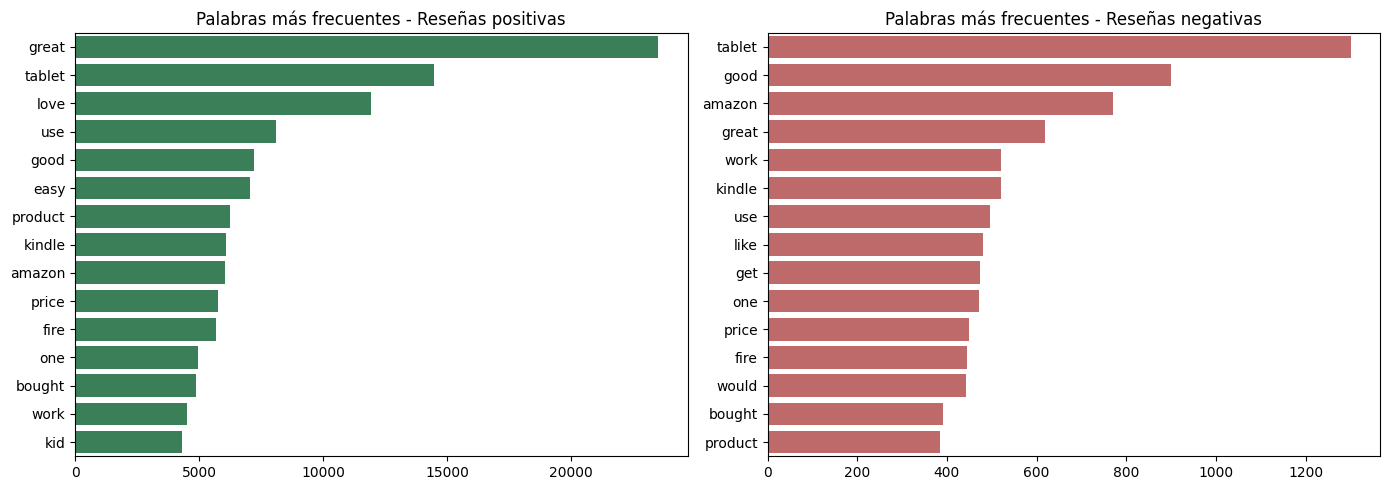

In [24]:
from collections import Counter

def top_palabras(textos, n=15):
    todas = " ".join(textos).split()
    return Counter(todas).most_common(n)

top_pos = top_palabras(df[df["sentimiento"] == 1]["texto_limpio"])
top_neg = top_palabras(df[df["sentimiento"] == 0]["texto_limpio"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=[c for _, c in top_pos], y=[p for p, _ in top_pos], ax=axes[0], color="seagreen")
axes[0].set_title("Palabras más frecuentes - Reseñas positivas")

sns.barplot(x=[c for _, c in top_neg], y=[p for p, _ in top_neg], ax=axes[1], color="indianred")
axes[1].set_title("Palabras más frecuentes - Reseñas negativas")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["texto_limpio"]
y = df["sentimiento"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train_text.shape[0], " Test:", X_test_text.shape[0])
print("Proporción de clases en train:")
print(y_train.value_counts(normalize=True))

Train: 27728  Test: 6932
Proporción de clases en train:
sentimiento
1    0.932379
0    0.067621
Name: proportion, dtype: float64


In [26]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

X_train_tfidf.shape, X_test_tfidf.shape

((27728, 5000), (6932, 5000))

In [27]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
modelo_lr.fit(X_train_tfidf, y_train)

y_pred_lr = modelo_lr.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy Regresión Logística:", round(acc_lr, 4))
print(classification_report(y_test, y_pred_lr, target_names=["Negativa", "Positiva"]))

Accuracy Regresión Logística: 0.8797
              precision    recall  f1-score   support

    Negativa       0.33      0.74      0.46       469
    Positiva       0.98      0.89      0.93      6463

    accuracy                           0.88      6932
   macro avg       0.65      0.82      0.69      6932
weighted avg       0.94      0.88      0.90      6932



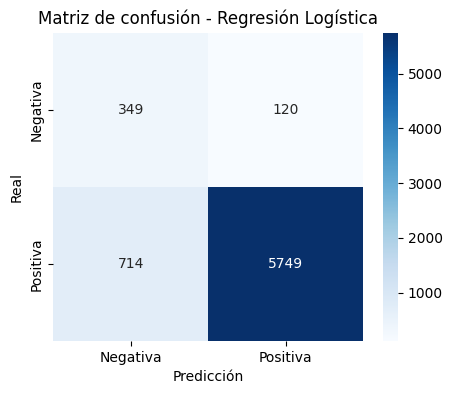

In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativa", "Positiva"], yticklabels=["Negativa", "Positiva"])
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 100

tokenizer_keras = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(X_train_text)

X_train_seq = tokenizer_keras.texts_to_sequences(X_train_text)
X_test_seq = tokenizer_keras.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad.shape, X_test_pad.shape

((27728, 100), (6932, 100))

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

modelo_dl = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

modelo_dl.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo_dl.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
pesos_dict = {0: pesos[0], 1: pesos[1]}
pesos_dict

{0: np.float64(7.3941333333333334), 1: np.float64(0.5362627161257881)}

In [32]:
historia = modelo_dl.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    class_weight=pesos_dict,
    verbose=1
)

Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7857 - loss: 0.6834 - val_accuracy: 0.1904 - val_loss: 0.7493
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7675 - loss: 0.5553 - val_accuracy: 0.8832 - val_loss: 0.3414
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8143 - loss: 0.4408 - val_accuracy: 0.8262 - val_loss: 0.3910
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8357 - loss: 0.3951 - val_accuracy: 0.9023 - val_loss: 0.2602
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8544 - loss: 0.3667 - val_accuracy: 0.8027 - val_loss: 0.4289
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8671 - loss: 0.3474 - val_accuracy: 0.8608 - val_loss: 0.3305
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8687 - loss: 0.3315 - val_accuracy: 0.8020 - val_loss: 0.4434
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8795 - loss: 0.3205 - val_accuracy: 0

In [34]:
y_pred_dl_proba = modelo_dl.predict(X_test_pad)
y_pred_dl = (y_pred_dl_proba > 0.5).astype(int).ravel()

acc_dl = accuracy_score(y_test, y_pred_dl)
print("Accuracy Red Neuronal (Deep Learning):", round(acc_dl, 4))
print(classification_report(y_test, y_pred_dl, target_names=["Negativa", "Positiva"]))

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy Red Neuronal (Deep Learning): 0.863
              precision    recall  f1-score   support

    Negativa       0.30      0.75      0.43       469
    Positiva       0.98      0.87      0.92      6463

    accuracy                           0.86      6932
   macro avg       0.64      0.81      0.67      6932
weighted avg       0.93      0.86      0.89      6932



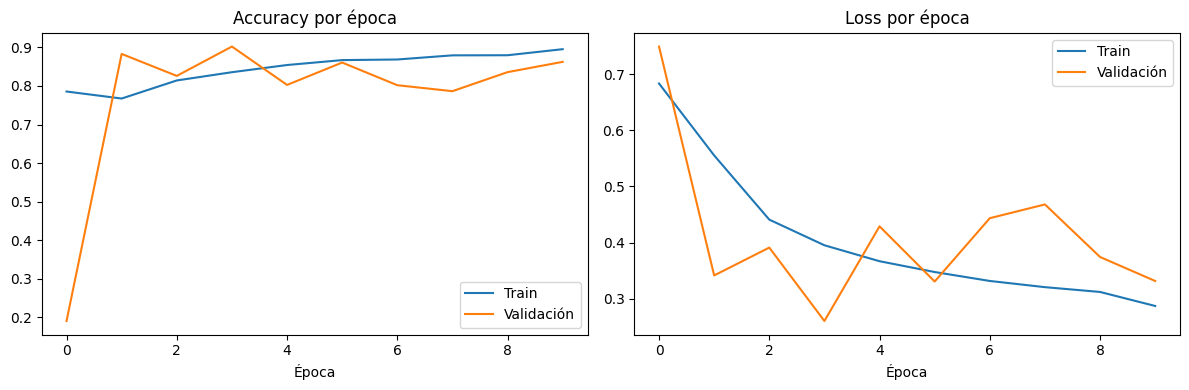

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia.history["accuracy"], label="Train")
axes[0].plot(historia.history["val_accuracy"], label="Validación")
axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(historia.history["loss"], label="Train")
axes[1].plot(historia.history["val_loss"], label="Validación")
axes[1].set_title("Loss por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

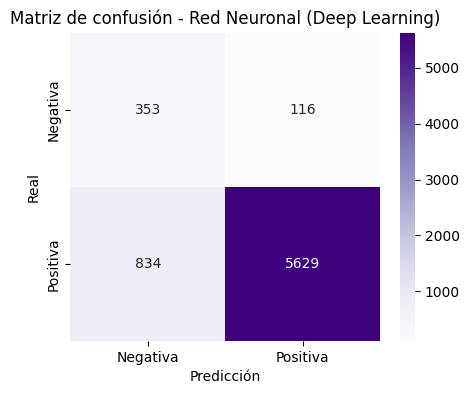

In [35]:
cm_dl = confusion_matrix(y_test, y_pred_dl)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Negativa", "Positiva"], yticklabels=["Negativa", "Positiva"])
plt.title("Matriz de confusión - Red Neuronal (Deep Learning)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [36]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average="macro")
f1_dl = f1_score(y_test, y_pred_dl, average="macro")

comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística (TF-IDF)", "Red Neuronal (Embedding - Keras)"],
    "Accuracy": [acc_lr, acc_dl],
    "F1-score (macro)": [f1_lr, f1_dl]
})
comparacion

,Modelo,Accuracy,F1-score (macro)
0,Regresión Logística (TF-IDF),0.879688,0.693992
1,Red Neuronal (Embedding - Keras),0.862954,0.674255


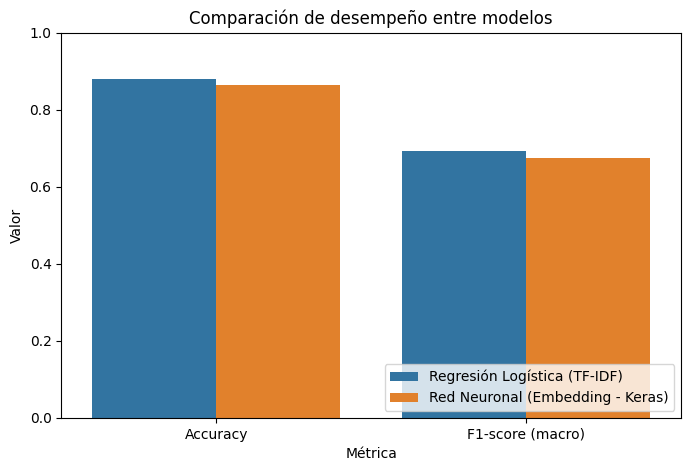

In [37]:
comparacion_melt = comparacion.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(8, 5))
sns.barplot(data=comparacion_melt, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparación de desempeño entre modelos")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

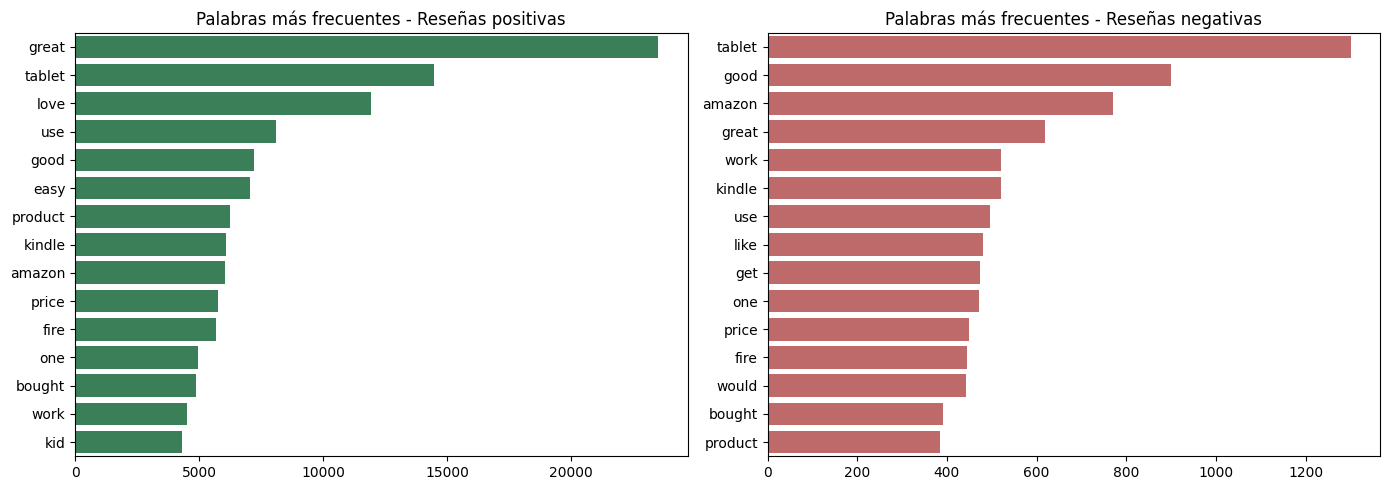

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=[c for _, c in top_pos], y=[p for p, _ in top_pos], ax=axes[0], color="seagreen")
axes[0].set_title("Palabras más frecuentes - Reseñas positivas")

sns.barplot(x=[c for _, c in top_neg], y=[p for p, _ in top_neg], ax=axes[1], color="indianred")
axes[1].set_title("Palabras más frecuentes - Reseñas negativas")

plt.tight_layout()
plt.show()